# Final product 1: One point to one area time series
We calculate the Jensen-Shannon dissimilarity metric for two radiuses based on a center location, in time.

In [1]:
import geopandas as gpd
import math
import pandas as pd
from shapely.geometry import Point, Polygon
import os
import dask
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy
import zarr
import re
import gc

In [2]:
# to install geopy, open a terminal then:
# conda activate sentinelhub
# pip install geopy
import geopy.distance

In [3]:
# We will use xcube to access Sentinel-2 imagery and create a lazy xarray cube
from xcube.core.store import new_data_store


A spatial extent is a bounding box that specifies the minimum and maximum longitude and latitude of the region of interest you want to process.

By default, this latitude, and longitude values are expressed in the standard Coordinate Reference System for the world, which is EPSG:4623, also known as “WGS 84”, or just “lat-long”.

In this example, we will use a data point from one EC -tower

https://fluxnet.org/sites/siteinfo/ES-LM1


In [4]:
def calculate_bounding_box(center_lat, center_lon, distance_km):
    earth_radius_km = 6371.0  # Radius of the Earth in kilometers

    # Convert distance to radians
    distance_lat = math.degrees(distance_km / earth_radius_km)
    distance_lon = distance_lat / math.cos(math.radians(center_lat))
    distance_lon = distance_lat

    # Calculate bounding box corners in WGS84 coordinates
    min_lat = center_lat - distance_lat
    max_lat = center_lat + distance_lat
    min_lon = center_lon - distance_lon
    max_lon = center_lon + distance_lon

    return [min_lon, min_lat, max_lon, max_lat]

In [5]:
from pyproj import CRS, Transformer
from shapely.geometry import Point
from shapely.ops import transform

def geodesic_point_buffer(lat, lon, km):
    # Azimuthal equidistant projection
    aeqd_proj = CRS.from_proj4(
        f"+proj=aeqd +lat_0={lat} +lon_0={lon} +x_0=0 +y_0=0")
    tfmr = Transformer.from_proj(aeqd_proj, aeqd_proj.geodetic_crs)
    buf = Point(0, 0).buffer(km * 1000)  # distance in metres
    arr = np.array(transform(tfmr.transform, buf).exterior.coords[:])
    
    return [arr[:,0].min(), arr[:,1].min(), arr[:,0].max(), arr[:,1].max()]


We will create a bounding box based on a point and a radius in kilometers. In this example, the coordinates of the point are ```39.94269,-5.778683```, and the radius is ```3``` kilometers.

In [6]:
bbox_majadas = geodesic_point_buffer(39.94269,-5.778683, 3)
bbox_majadas

[-5.813785003206277, 39.9156710718201, -5.743580996793722, 39.96970880187782]

CDSE credentials for Sentinelhub, for more informantion see:

* How can I generate the credentials:
https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Overview/Authentication.html

* How can I use xcube with SentinelHub:
https://xcube.readthedocs.io/en/latest/api.html#xcube.core.store.new_data_store


In [7]:
sh_config = dict(client_id = '',
                 client_secret =  '',
                 oauth2_url = 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect',
                 api_url = 'https://sh.dataspace.copernicus.eu')

In [8]:
store = new_data_store('sentinelhub', **sh_config)

In [9]:
dataset_majadas = store.open_data('S2L2A',
                         variable_names = ['B07', 'B03', 'SCL'],
                         bbox = bbox_majadas,
                         spatial_res = 0.00018,
                         time_range = ('2023-05-01', '2024-05-01'),
                                 chunks={'time': -1, 
                                         'lat':-1,
                                        'lon':-1})

/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:254: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt = pd.to_datetime(dt, infer_datetime_format=True, utc=True)
/opt/conda/envs/sentinelhub/lib/python3.10/site-packages/xcube_sh/sentinelhub.py:317: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  pd.to_timedelta(max_timedelta)


In [10]:
dataset_majadas

<xarray.Dataset>
Dimensions:    (time: 74, lat: 300, lon: 390, bnds: 2)
Coordinates:
  * lat        (lat) float64 39.97 39.97 39.97 39.97 ... 39.92 39.92 39.92 39.92
  * lon        (lon) float64 -5.814 -5.814 -5.813 ... -5.744 -5.744 -5.744
  * time       (time) datetime64[ns] 2023-05-01T11:20:11 ... 2024-04-30T11:20:11
    time_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(74, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    B03        (time, lat, lon) float32 dask.array<chunksize=(74, 300, 390), meta=np.ndarray>
    B07        (time, lat, lon) float32 dask.array<chunksize=(74, 300, 390), meta=np.ndarray>
    SCL        (time, lat, lon) uint8 dask.array<chunksize=(74, 300, 390), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   S2L2A Data Cube Subset
    history:                 [{'program': 'xcube_sh.chunkstore.SentinelHubChu...
    date_created:            2024-09-10T13:37:21.556545
    time_coverage_start:     2023-05-01T11:20:11.695000+00:00
    time_coverage_end:       2024-04-30T11:20:11.526000+00:00
    time_coverage_duration:  P364DT23H59M59.831S
    geospatial_lon_min:      -5.813785003206277
    geospatial_lat_min:      39.9156710718201
    geospatial_lon_max:      -5.743585003206277
    geospatial_lat_max:      39.9696710718201
    processing_level:        L2A

### Visual inspection of the cube

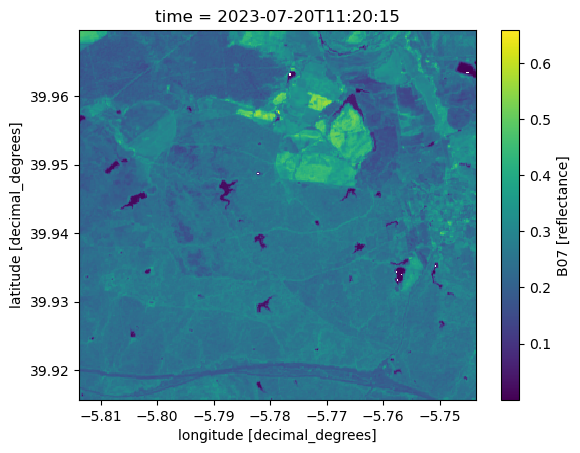

In [11]:
# Band B7
dataset_majadas['B07'].sel(time = "2023-07-20").plot()

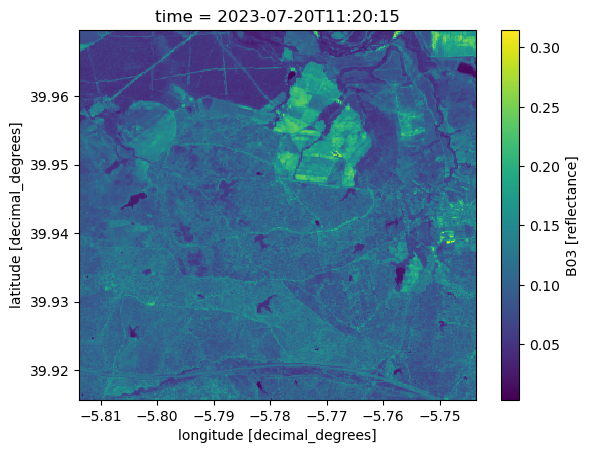

In [12]:
# Band B3
dataset_majadas['B03'].sel(time = "2023-07-20").plot()

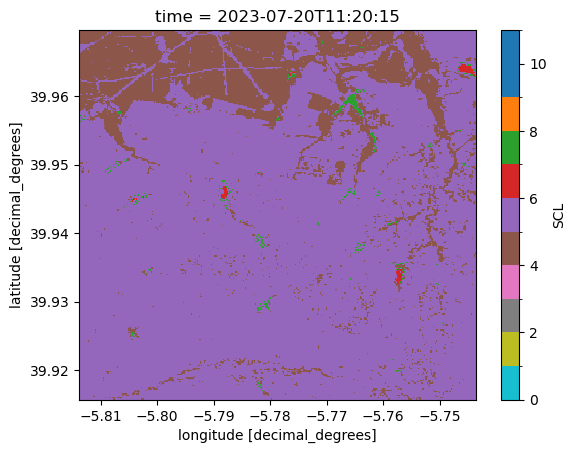

In [13]:
# Scene classification
dataset_majadas['SCL'].sel(time = '2023-07-20').plot(levels=[0, 1, 2,3,4,5,6,7,8,9,10,11], colors = 'tab10_r')

### Masking based on the SCL variable

In this exercise we will focus only on the differences of earth surface where we have good observations without clouds or clouds shadows, Then we will only consider the classes ```4,5,6,11``` corresponding to: 

4 => vegetation

5 => bare_soils

6 => water

11 => snow_or_ice

For more details on the Scene classes run ```store.describe_data('S2L2A')```

In [14]:
dataset_majadas_filtered = dataset_majadas.where(dataset_majadas['SCL'].isin([4,5,6,11]))

### Computing Red-edge chlorophyll index (CIR)

In [15]:
cir = (dataset_majadas_filtered['B07'] /  dataset_majadas_filtered['B03']) - 1

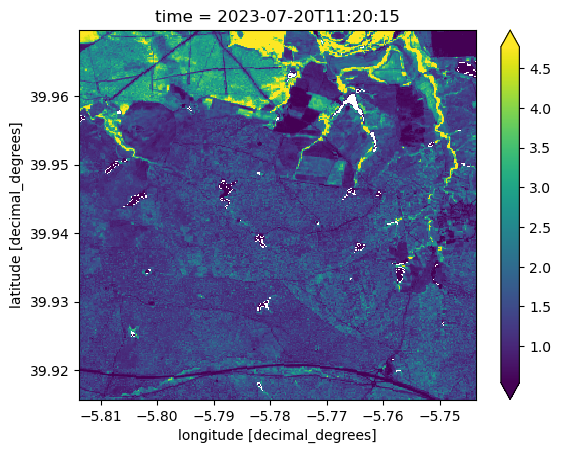

In [16]:
# Visual inspection of the CIR
cir.sel(time = "2023-07-20").plot(robust=True)

### Creating a distance matrix from the eddy covariance tower

To mask values corresponding a certain distance from the tower we need to compute the distance of each pixel to the tower.

In [17]:
tower_location = (39.94269,-5.778683)

# Create a dummy matrix to save the data
dist_mat = np.zeros((len(cir.lat.data), len(cir.lon.data)))
lat = cir.lat.data
lon = cir.lon.data

In [18]:
#lat[0:len(lat)]

In [19]:
for la in range(len(lat)):
    for lo in range(len(lon)):
        dist_mat[la,lo] = geopy.distance.geodesic(tower_location, (lat[la], lon[lo])).m

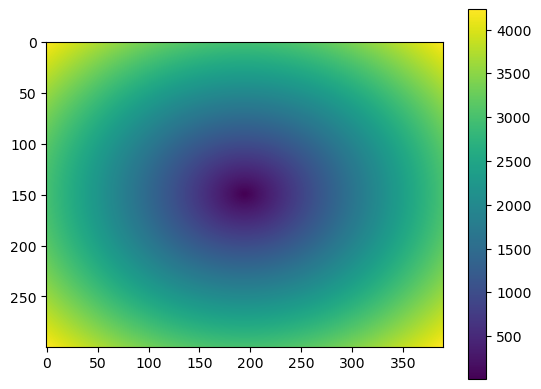

In [20]:
plt.imshow(dist_mat)
plt.colorbar()
plt.show()

Adding the distance_tower matrix to the CIR dataset

In [21]:
cir_dataset = cir.to_dataset(name = "cir")
cir_dataset

<xarray.Dataset>
Dimensions:  (lat: 300, lon: 390, time: 74)
Coordinates:
  * lat      (lat) float64 39.97 39.97 39.97 39.97 ... 39.92 39.92 39.92 39.92
  * lon      (lon) float64 -5.814 -5.814 -5.813 -5.813 ... -5.744 -5.744 -5.744
  * time     (time) datetime64[ns] 2023-05-01T11:20:11 ... 2024-04-30T11:20:11
Data variables:
    cir      (time, lat, lon) float32 dask.array<chunksize=(74, 300, 390), meta=np.ndarray>

In [22]:
cir_dataset = cir_dataset.assign(distance_tower = (['lat', 'lon'], dist_mat))

In [23]:
cir_dataset

<xarray.Dataset>
Dimensions:         (lat: 300, lon: 390, time: 74)
Coordinates:
  * lat             (lat) float64 39.97 39.97 39.97 39.97 ... 39.92 39.92 39.92
  * lon             (lon) float64 -5.814 -5.814 -5.813 ... -5.744 -5.744 -5.744
  * time            (time) datetime64[ns] 2023-05-01T11:20:11 ... 2024-04-30T...
Data variables:
    cir             (time, lat, lon) float32 dask.array<chunksize=(74, 300, 390), meta=np.ndarray>
    distance_tower  (lat, lon) float64 4.227e+03 4.216e+03 ... 4.23e+03

### Function to compute Jensen-Shannon distance
 We will use the function to estimate the Jensen-Shannon (JS) distance for two radius around the tower. For more information about the Jensen-Shannon distance see:
 https://www.mdpi.com/1099-4300/21/5/485

In [34]:
def dissimilarity(cube_point, cube_area):
    gc.collect()
    # allocating output object
    #out_tmp = np.full(len(tower_foot)*len(satellite_foot), np.nan)
    #print(f"received x of type {type(cube_tower)}, shape {cube_satellite.shape}")
    #print(f"received y of type {type(cube_satellite)}")
    
    point = np.ravel(cube_point)
    area = np.ravel(cube_area)

    
    if np.isnan(point).all() or  np.isnan(area).all():
        return np.repeat(np.nan,3)
        
    else:
        point = point[~np.isnan(point)]
        area = area[~np.isnan(area)]
        
        try:
            # Estimate the KDE for each vector
            kde1 = scipy.stats.gaussian_kde(point)
            kde2 = scipy.stats.gaussian_kde(area)

            # Create a range of values for the x-axis
            x_values = np.linspace(min(point.min(), area.min()), max(point.max(), area.max()), 100)

            # Get the KDE values at specific points for each vector
            kde_values1 = kde1.evaluate(x_values)
            kde_values2 = kde2.evaluate(x_values)
            
            js_metric = scipy.spatial.distance.jensenshannon(kde_values1, kde_values2)
            
        except:
            js_metric = np.nan
    
    
        #e_statistics = energy_statistics.get_energy_statistics(tower, satellite)
    
        return np.array([js_metric, np.count_nonzero(~np.isnan(point)), np.count_nonzero(~np.isnan(area))])
    # e_statistics.e, e_statistics.t, e_statistics.h
    
    gc.collect()


### Estimating Jensen-Shannon distance from point to area

Defining a tower footprint (point) and one satellite footprint (area)

In [35]:
point_radius = 50
area_radius = 3000

In [36]:
# Point data
point_cube = cir_dataset.where(cir_dataset["distance_tower"] <= point_radius) 

In [37]:
# Area data

area_cube = cir_dataset.where(cir_dataset["distance_tower"] < area_radius) 

In [38]:
results_cube = xr.apply_ufunc(dissimilarity, point_cube, area_cube,
                              input_core_dims=[['lat','lon'], ['lat','lon']],
                              output_core_dims=[['stats']],
                              output_sizes = {'stats':3},
                              output_dtypes= [np.float64],
                              vectorize=True,
                              dask= "parallelized")

/tmp/ipykernel_232/1937955581.py:1: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  results_cube = xr.apply_ufunc(dissimilarity, point_cube, area_cube,


In [39]:
res = results_cube.compute()

In [40]:
res = res.assign_coords({"stats": ["JS","n_point", "n_area"]})

In [41]:
tmp_dataframe = res.to_dataframe()

In [42]:
tmp_dataframe['point_radius'] = point_radius

In [43]:
tmp_dataframe['area_radius'] = area_radius

In [44]:
tmp_dataframe.to_csv("/home/jovyan/mystorage/results/""ES-LM1_point_"+str(point_radius)+"_area_"+str(area_radius)+".csv")
gc.collect()

0

# Checking the results


In [45]:
majadas_res = pd.read_csv("/home/jovyan/mystorage/results/ES-LM1_point_50_area_3000.csv")
majadas_res

,time,stats,cir,distance_tower,point_radius,area_radius
0,2023-05-01 11:20:11,JS,NaN,0.830833,50,3000
1,2023-05-01 11:20:11,n_point,NaN,25.000000,50,3000
2,2023-05-01 11:20:11,n_area,NaN,91967.000000,50,3000
3,2023-05-06 11:20:14,JS,0.398483,0.830833,50,3000
4,2023-05-06 11:20:14,n_point,25.000000,25.000000,50,3000
...,...,...,...,...,...,...
217,2024-04-25 11:20:13,n_point,NaN,25.000000,50,3000
218,2024-04-25 11:20:13,n_area,NaN,91967.000000,50,3000
219,2024-04-30 11:20:11,JS,NaN,0.830833,50,3000
220,2024-04-30 11:20:11,n_point,NaN,25.000000,50,3000


In [46]:
#majadas_res = majadas_res.dropna()

Function to compute the current amount of data on the ```point_area``` where radius correspond to ```point_radius```, res is the resolution of pixels in meters in this example 20 meters. ```thres```, is the threshold that we want consider masking out observations. For example, only keep where there is at least 80% of data points in the area.


In [47]:

def thrs_fun(radius, res, thres):
    theo_max = math.pi * ((radius / res) ** 2)
    thrs = round((theo_max * thres) / 100)
    return thrs


In [48]:
majadas_res['point_thrs'] = majadas_res.apply(lambda row: thrs_fun(row['point_radius'], 20, 80), axis=1)
majadas_res['area_thrs'] = majadas_res.apply(lambda row: thrs_fun(row['area_radius'], 20, 80), axis=1)

/tmp/ipykernel_232/3126159779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  majadas_res['point_thrs'] = majadas_res.apply(lambda row: thrs_fun(row['point_radius'], 20, 80), axis=1)
/tmp/ipykernel_232/3126159779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  majadas_res['area_thrs'] = majadas_res.apply(lambda row: thrs_fun(row['area_radius'], 20, 80), axis=1)


In [49]:
data_wide = majadas_res.pivot(index='time', columns='stats')
data_wide

cir                  distance_tower           \
stats                      JS   n_area n_point             JS   n_area   
time                                                                     
2023-05-06 11:20:14  0.398483  58055.0    25.0       0.830833  91967.0   
2023-05-11 11:20:10  0.282972  91218.0    25.0       0.830833  91967.0   
2023-06-05 11:20:15  0.325878  91195.0    25.0       0.830833  91967.0   
2023-06-10 11:20:15  0.347451  78399.0    25.0       0.830833  91967.0   
2023-06-15 11:20:16  0.385230  79962.0    25.0       0.830833  91967.0   
2023-06-25 11:20:15  0.382758  91071.0    25.0       0.830833  91967.0   
2023-06-30 11:20:15  0.336126  91343.0    25.0       0.830833  91967.0   
2023-07-05 11:20:16  0.368127  61356.0    25.0       0.830833  91967.0   
2023-07-10 11:20:16  0.281432  91423.0    25.0       0.830833  91967.0   
2023-07-15 11:20:16  0.258365  91427.0    25.0       0.830833  91967.0   
2023-07-20 11:20:15  0.253029  91402.0    25.0       0.830833  91967.0   
2023-07-25 11:20:17  0.255699  91487.0    25.0       0.830833  91967.0   
2023-07-30 11:20:16  0.243298  91588.0    25.0       0.830833  91967.0   
2023-08-04 11:20:16  0.243324  91577.0    25.0       0.830833  91967.0   
2023-08-14 11:20:17  0.237280  91574.0    25.0       0.830833  91967.0   
2023-08-19 11:20:17  0.218134  91613.0    25.0       0.830833  91967.0   
2023-08-24 11:20:15  0.245682  91566.0    25.0       0.830833  91967.0   
2023-08-29 11:20:17  0.246405  73525.0    25.0       0.830833  91967.0   
2023-09-13 11:20:14  0.236196  91572.0    25.0       0.830833  91967.0   
2023-09-23 11:20:15  0.254349  91557.0    25.0       0.830833  91967.0   
2023-09-28 11:20:13  0.222081  91637.0    25.0       0.830833  91967.0   
2023-10-03 11:20:12  0.259307  91967.0    25.0       0.830833  91967.0   
2023-11-22 11:20:07  0.332826  91948.0    25.0       0.830833  91967.0   
2023-12-02 11:20:08  0.389313  91966.0    25.0       0.830833  91967.0   
2023-12-17 11:20:07  0.422736  91964.0    25.0       0.830833  91967.0   
2023-12-22 11:20:12  0.434940  91960.0    25.0       0.830833  91967.0   
2024-01-06 11:20:07  0.340829  91926.0    25.0       0.830833  91967.0   
2024-02-10 11:20:11  0.494059  62087.0    25.0       0.830833  91967.0   
2024-02-20 11:20:12  0.386576  91896.0    25.0       0.830833  91967.0   
2024-03-01 11:20:09  0.414221  91967.0    25.0       0.830833  91967.0   
2024-03-06 11:20:12  0.418816  88753.0    25.0       0.830833  91967.0   
2024-03-11 11:20:07  0.389928  88963.0    25.0       0.830833  91967.0   
2024-03-21 11:20:11  0.498697  86302.0    25.0       0.830833  91967.0   
2024-04-10 11:20:11  0.565370  90986.0    25.0       0.830833  91967.0   
2024-04-15 11:20:14  0.509816  91131.0    25.0       0.830833  91967.0   

                            point_radius                area_radius         \
stats               n_point           JS n_area n_point          JS n_area   
time                                                                         
2023-05-06 11:20:14    25.0           50     50      50        3000   3000   
2023-05-11 11:20:10    25.0           50     50      50        3000   3000   
2023-06-05 11:20:15    25.0           50     50      50        3000   3000   
2023-06-10 11:20:15    25.0           50     50      50        3000   3000   
2023-06-15 11:20:16    25.0           50     50      50        3000   3000   
2023-06-25 11:20:15    25.0           50     50      50        3000   3000   
2023-06-30 11:20:15    25.0           50     50      50        3000   3000   
2023-07-05 11:20:16    25.0           50     50      50        3000   3000   
2023-07-10 11:20:16    25.0           50     50      50        3000   3000   
2023-07-15 11:20:16    25.0           50     50      50        3000   3000   
2023-07-20 11:20:15    25.0           50     50      50        3000   3000   
2023-07-25 11:20:17    25.0           50     50      50        3000   3000   
2023-07-30 11:20:16    25.0           50   

In [50]:
# Filter based on the conditions
filtered_data = data_wide[
    (data_wide['cir']['n_point'] >= data_wide['point_thrs']['n_point']) & 
    (data_wide['cir']['n_area'] >= data_wide['area_thrs']['n_area'])
]
filtered_data

cir                  distance_tower           \
stats                      JS   n_area n_point             JS   n_area   
time                                                                     
2023-05-06 11:20:14  0.398483  58055.0    25.0       0.830833  91967.0   
2023-05-11 11:20:10  0.282972  91218.0    25.0       0.830833  91967.0   
2023-06-05 11:20:15  0.325878  91195.0    25.0       0.830833  91967.0   
2023-06-10 11:20:15  0.347451  78399.0    25.0       0.830833  91967.0   
2023-06-15 11:20:16  0.385230  79962.0    25.0       0.830833  91967.0   
2023-06-25 11:20:15  0.382758  91071.0    25.0       0.830833  91967.0   
2023-06-30 11:20:15  0.336126  91343.0    25.0       0.830833  91967.0   
2023-07-05 11:20:16  0.368127  61356.0    25.0       0.830833  91967.0   
2023-07-10 11:20:16  0.281432  91423.0    25.0       0.830833  91967.0   
2023-07-15 11:20:16  0.258365  91427.0    25.0       0.830833  91967.0   
2023-07-20 11:20:15  0.253029  91402.0    25.0       0.830833  91967.0   
2023-07-25 11:20:17  0.255699  91487.0    25.0       0.830833  91967.0   
2023-07-30 11:20:16  0.243298  91588.0    25.0       0.830833  91967.0   
2023-08-04 11:20:16  0.243324  91577.0    25.0       0.830833  91967.0   
2023-08-14 11:20:17  0.237280  91574.0    25.0       0.830833  91967.0   
2023-08-19 11:20:17  0.218134  91613.0    25.0       0.830833  91967.0   
2023-08-24 11:20:15  0.245682  91566.0    25.0       0.830833  91967.0   
2023-08-29 11:20:17  0.246405  73525.0    25.0       0.830833  91967.0   
2023-09-13 11:20:14  0.236196  91572.0    25.0       0.830833  91967.0   
2023-09-23 11:20:15  0.254349  91557.0    25.0       0.830833  91967.0   
2023-09-28 11:20:13  0.222081  91637.0    25.0       0.830833  91967.0   
2023-10-03 11:20:12  0.259307  91967.0    25.0       0.830833  91967.0   
2023-11-22 11:20:07  0.332826  91948.0    25.0       0.830833  91967.0   
2023-12-02 11:20:08  0.389313  91966.0    25.0       0.830833  91967.0   
2023-12-17 11:20:07  0.422736  91964.0    25.0       0.830833  91967.0   
2023-12-22 11:20:12  0.434940  91960.0    25.0       0.830833  91967.0   
2024-01-06 11:20:07  0.340829  91926.0    25.0       0.830833  91967.0   
2024-02-10 11:20:11  0.494059  62087.0    25.0       0.830833  91967.0   
2024-02-20 11:20:12  0.386576  91896.0    25.0       0.830833  91967.0   
2024-03-01 11:20:09  0.414221  91967.0    25.0       0.830833  91967.0   
2024-03-06 11:20:12  0.418816  88753.0    25.0       0.830833  91967.0   
2024-03-11 11:20:07  0.389928  88963.0    25.0       0.830833  91967.0   
2024-03-21 11:20:11  0.498697  86302.0    25.0       0.830833  91967.0   
2024-04-10 11:20:11  0.565370  90986.0    25.0       0.830833  91967.0   
2024-04-15 11:20:14  0.509816  91131.0    25.0       0.830833  91967.0   

                            point_radius                area_radius         \
stats               n_point           JS n_area n_point          JS n_area   
time                                                                         
2023-05-06 11:20:14    25.0           50     50      50        3000   3000   
2023-05-11 11:20:10    25.0           50     50      50        3000   3000   
2023-06-05 11:20:15    25.0           50     50      50        3000   3000   
2023-06-10 11:20:15    25.0           50     50      50        3000   3000   
2023-06-15 11:20:16    25.0           50     50      50        3000   3000   
2023-06-25 11:20:15    25.0           50     50      50        3000   3000   
2023-06-30 11:20:15    25.0           50     50      50        3000   3000   
2023-07-05 11:20:16    25.0           50     50      50        3000   3000   
2023-07-10 11:20:16    25.0           50     50      50        3000   3000   
2023-07-15 11:20:16    25.0           50     50      50        3000   3000   
2023-07-20 11:20:15    25.0           50     50      50        3000   3000   
2023-07-25 11:20:17    25.0           50     50      50        3000   3000   
2023-07-30 11:20:16    25.0           50   

In [51]:
# Extract JS data
js_data = filtered_data[('cir', 'JS')]
js_data

time
2023-05-06 11:20:14    0.398483
2023-05-11 11:20:10    0.282972
2023-06-05 11:20:15    0.325878
2023-06-10 11:20:15    0.347451
2023-06-15 11:20:16    0.385230
2023-06-25 11:20:15    0.382758
2023-06-30 11:20:15    0.336126
2023-07-05 11:20:16    0.368127
2023-07-10 11:20:16    0.281432
2023-07-15 11:20:16    0.258365
2023-07-20 11:20:15    0.253029
2023-07-25 11:20:17    0.255699
2023-07-30 11:20:16    0.243298
2023-08-04 11:20:16    0.243324
2023-08-14 11:20:17    0.237280
2023-08-19 11:20:17    0.218134
2023-08-24 11:20:15    0.245682
2023-08-29 11:20:17    0.246405
2023-09-13 11:20:14    0.236196
2023-09-23 11:20:15    0.254349
2023-09-28 11:20:13    0.222081
2023-10-03 11:20:12    0.259307
2023-11-22 11:20:07    0.332826
2023-12-02 11:20:08    0.389313
2023-12-17 11:20:07    0.422736
2023-12-22 11:20:12    0.434940
2024-01-06 11:20:07    0.340829
2024-02-10 11:20:11    0.494059
2024-02-20 11:20:12    0.386576
2024-03-01 11:20:09    0.414221
2024-03-06 11:20:12    0.418816
202

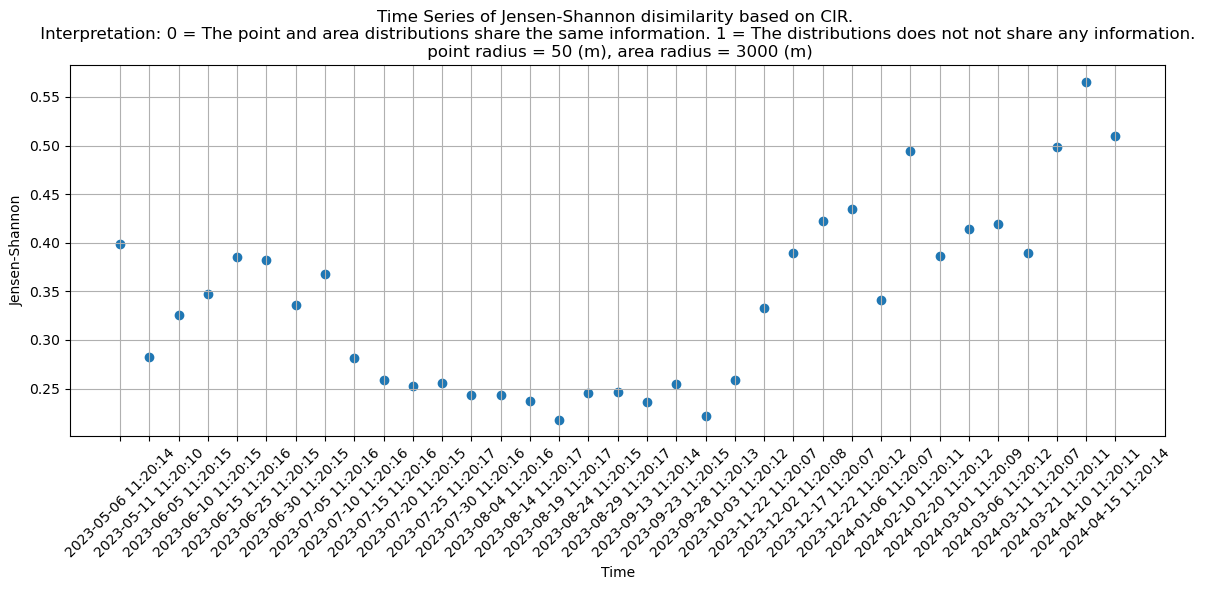

In [53]:
# Plot the time series

plt.figure(figsize=(12, 6))  # Increase plot width

plt.scatter(js_data.index, js_data.values)
plt.xlabel('Time')
plt.ylabel('Jensen-Shannon')
plt.title('Time Series of Jensen-Shannon disimilarity based on CIR. \n Interpretation: 0 = The point and area distributions share the same information. 1 = The distributions does not not share any information. \n point radius = '+ str(point_radius) +' (m), area radius = ' + str(area_radius) + ' (m)')
plt.grid(True)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Format x-axis dates
#date_format = dates.DateFormatter('%Y-%m-%d')
#plt.gca().xaxis.set_major_formatter(date_format)

# Adjust spacing between ticks
plt.tight_layout()

plt.show()